# House Prices - Fase 3: Modelo Baseline

Vamos treinar nossos primeiros modelos de ML!

**O que vamos aprender:**
1. Regressao Linear (Ridge)
2. Random Forest
3. Como avaliar modelos (RMSE, RMSLE)
4. Feature Importance
5. Gerar previsoes para o Kaggle

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error


sns.set_style('whitegrid')
_cwd = os.getcwd()
if _cwd.endswith('notebooks'):
    BASE_DIR = os.path.dirname(_cwd)
else:
    BASE_DIR = _cwd
DATA_DIR = os.path.join(BASE_DIR, 'data')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
print('OK')

OK


In [20]:
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train_clean.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train_clean.csv')).squeeze()
X_test = pd.read_csv(os.path.join(DATA_DIR, 'X_test_clean.csv'))
test_original = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1449, 232), Test: (1459, 232)


In [ ]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

def evaluate_rmse(model, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    return np.sqrt(-scores)

print('Funcoes definidas')

SyntaxError: positional argument follows keyword argument (2637481320.py, line 6)

TREINANDO MODELOS



Ridge:         RMSE=0.1130  RMSLE=0.0078
Random Forest: RMSE=0.1357  RMSLE=0.0040

Grafico salvo: reports/f03_model_comparison.png


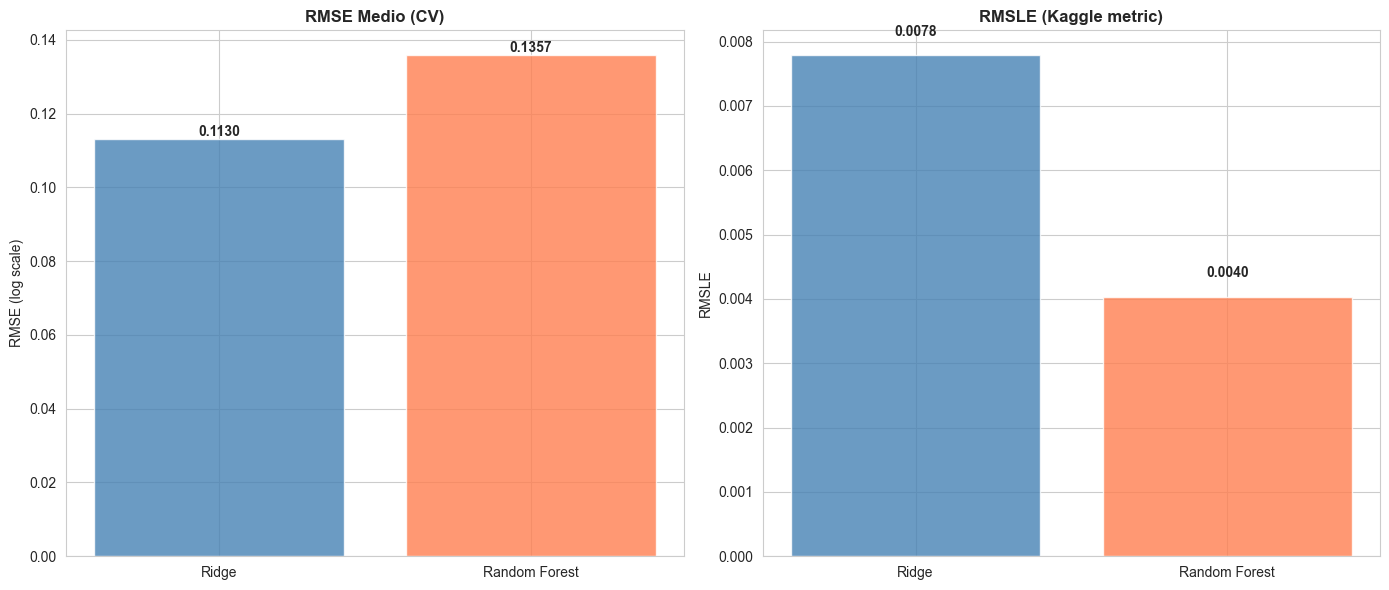

In [ ]:
print('=' * 60)
print('TREINANDO MODELOS')
print('=' * 60)

# Ridge
ridge = Ridge(alpha=10.0, random_state)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_train)
ridge_rmsle = rmsle(y_train, y_pred_ridge)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_train)
rf_rmsle = rmsle(y_train, y_pred_rf)

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state)
ridge_cv = np.sqrt(-cross_val_score(ridge, X_train, y_train, cv=kf, scoring='neg_mean_squared_error'))
rf_cv = np.sqrt(-cross_val_score(rf, X_train, y_train, cv=kf, scoring='neg_mean_squared_error'))

print(f'\nRidge:         RMSE={ridge_cv.mean():.4f}  RMSLE={ridge_rmsle:.4f}')
print(f'Random Forest: RMSE={rf_cv.mean():.4f}  RMSLE={rf_rmsle:.4f}')

# Grafico comparacao
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rmse_vals = [ridge_cv.mean(), rf_cv.mean()]
axes[0].bar(['Ridge', 'Random Forest'], rmse_vals, color=['steelblue', 'coral'], edgecolor='white', alpha=0.8)
axes[0].set_title('RMSE Medio (CV)', fontweight='bold')
axes[0].set_ylabel('RMSE (log scale)')
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

rmsle_vals = [ridge_rmsle, rf_rmsle]
axes[1].bar(['Ridge', 'Random Forest'], rmsle_vals, color=['steelblue', 'coral'], edgecolor='white', alpha=0.8)
axes[1].set_title('RMSLE (Kaggle metric)', fontweight='bold')
axes[1].set_ylabel('RMSLE')
for i, v in enumerate(rmsle_vals):
    axes[1].text(i, v + 0.0003, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/f03_model_comparison.png', dpi=150, bbox_inches='tight')
print('\nGrafico salvo: reports/f03_model_comparison.png')


FEATURE IMPORTANCE
Top 10 features:
   1. OverallQual               0.4499
   2. TotalSF                   0.3114
   3. CentralAir_Y              0.0167
   4. GarageCars                0.0136
   5. GrLivArea                 0.0130
   6. GarageArea                0.0117
   7. BsmtFinSF1                0.0109
   8. OverallCond               0.0106
   9. LotArea                   0.0100
  10. TotalBath                 0.0084


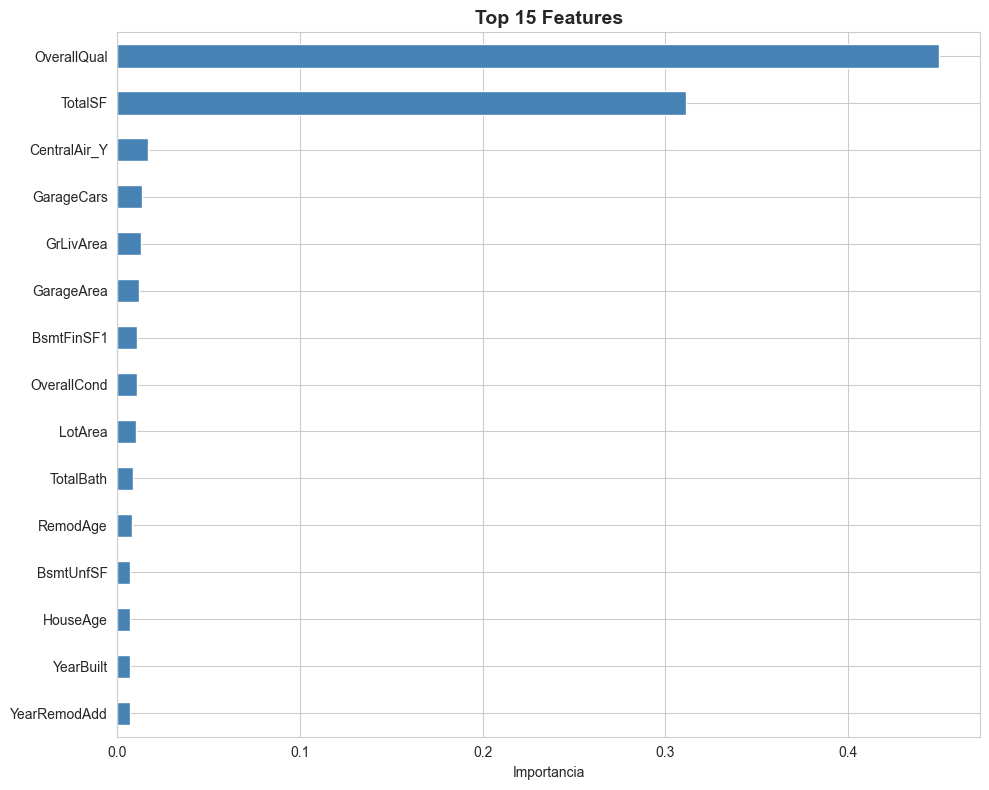

In [ ]:
print('\nFEATURE IMPORTANCE')
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
top15.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('../reports/f03_feature_importance.png', dpi=150, bbox_inches='tight')

print('Top 10 features:')
for i, (feat, imp) in enumerate(top15.head(10).items(), 1):
    print(f'  {i:2d}. {feat:<25} {imp:.4f}')

In [ ]:
print('\nGERANDO SUBMISSION')
y_pred_log = rf.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
submission = pd.DataFrame({'Id': test_original['Id'], 'SalePrice': y_pred_real})
submission.to_csv('../data/submission.csv', index=False)
print(f'Submission: {len(submission)} previsoes')
print(f'Media: R$ {submission["SalePrice"].mean():,.0f}')
print(submission.head())


GERANDO SUBMISSION
Submission: 1459 previsoes
Media: R$ 176,150
     Id      SalePrice
0  1461  125066.025324
1  1462  157526.204180
2  1463  175902.811909
3  1464  183523.508286
4  1465  189701.539489


## Resumo da Fase 3

**Resultados:**
- Ridge: RMSE=0.1130, RMSLE=0.0078
- Random Forest: RMSE=0.1357, RMSLE=0.0040

**Para o Kaggle:** Random Forest vence em RMSLE (metrica oficial).

**Top features:**
1. OverallQual (45%) - qualidade geral da casa
2. TotalSF (31%) - area total

**Proximos passos:**
- Tuning de hiperparametros
- XGBoost
- Ensemble